# 03 · Системы ОДУ

Связанные уравнения, по одному на переменную: Лотка-Вольтерра и Лоренц-63. Запуск возвращает систему; она засчитывается, только если верно каждое уравнение.

In [1]:
import os, sys, time
from pathlib import Path
os.environ.setdefault('OPENBLAS_NUM_THREADS', '1')   # before numpy: EPDE is faster single-threaded
os.environ.setdefault('OMP_NUM_THREADS', '1')

# find projects/pic (this notebook lives in projects/pic/notebooks)
PIC = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'epde_bench').is_dir())
sys.path[:0] = [str(PIC.parent.parent), str(PIC)]
import epde

import numpy as np
import matplotlib.pyplot as plt
from epde_bench import datasets, metrics, load_config, resolve_for_problem, discover
from epde_bench.plotting import plot_problem, plot_front
from epde_bench.truthcheck import check, print_check
%matplotlib inline
print('EPDE imported; PIC notebook environment ready')

EPDE imported; PIC notebook environment ready


## `lv` · Лотка-Вольтерра (хищник-жертва)

lv: Lotka-Volterra predator-prey
  class: system of ODEs, source: synthetic
  axes: t; data shape: (301,); variables: u, v
  t: [0, 0.9967], 301 points
  truth:
    20.0 * u{power: 1.0} + -20.0 * u{power: 1.0} * v{power: 1.0} = du/dx0{power: 1.0}
    20.0 * u{power: 1.0} * v{power: 1.0} + -20.0 * v{power: 1.0} = dv/dx0{power: 1.0}
  + 1 equivalent form(s)
  notes: alpha = beta = gamma = delta = 20, all 301 samples (lv.py used the first 150; gate.py explains why the full record is preferable).


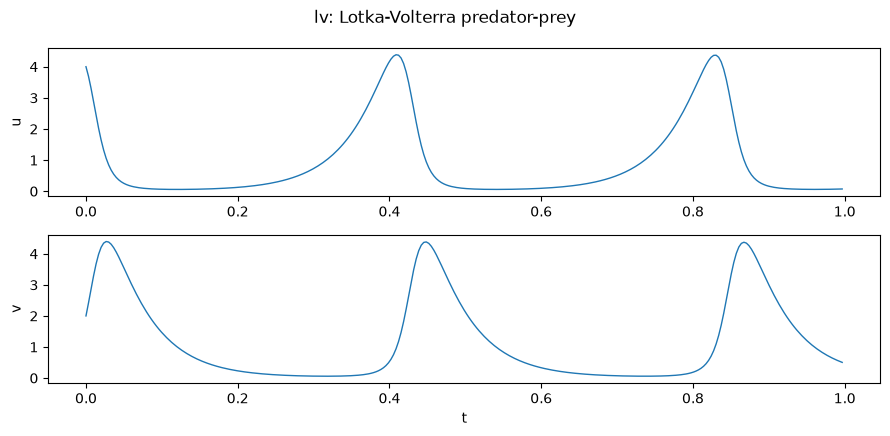

In [2]:
p = datasets.load('lv')
print(p.summary())
plot_problem(p); plt.show()

In [3]:
p, report = check('lv', noise_levels=[0, 1, 5])
print_check(p, report)

lv: Lotka-Volterra predator-prey
  class: system of ODEs, source: synthetic
  axes: t; data shape: (301,); variables: u, v
  t: [0, 0.9967], 301 points
  truth:
    20.0 * u{power: 1.0} + -20.0 * u{power: 1.0} * v{power: 1.0} = du/dx0{power: 1.0}
    20.0 * u{power: 1.0} * v{power: 1.0} + -20.0 * v{power: 1.0} = dv/dx0{power: 1.0}
  + 1 equivalent form(s)
  notes: alpha = beta = gamma = delta = 20, all 301 samples (lv.py used the first 150; gate.py explains why the full record is preferable).

=== noise 0 % ===
R^2 of the true structure: 0.999972   (du/dx0{power: 1.0})
  term                                                             true       fitted  R^2 lost if dropped
  u{'power': 1.0}                                                    20       19.914            3.380e-01
  u{'power': 1.0} * v{'power': 1.0}                                 -20      -19.893            1.000e+00
R^2 of the true structure: 0.999973   (dv/dx0{power: 1.0})
  term                                         

In [4]:
from epde_bench.nbcache import cached_run
rec = cached_run('lv', variant='default', noise=0.0, seed=0)
print(rec['status'], f"fit {rec.get('fit_seconds', 0):.0f} s", '(from cache)' if rec.get('from_cache') else '')
for i, system in enumerate(rec.get('front', [])):
    print(f'[{i}]' + (' <- compromise pick' if i == rec['metrics']['selected_index'] else ''))
    for eq in system:
        print('    ', eq)
print({k: v for k, v in rec.get('metrics', {}).items() if k != 'best_index'})
if rec['status'] != 'ok':
    print('Search needs attention:', rec.get('error', rec['status']))

ok fit 101 s (from cache)
[0]
     / 574.0711551499951 * u{power: 2.0} + 32.913534714925866 * v{power: 3.0} + 106.78063524268043 * dv/dx0{power: 1.0} * u{power: 1.0} + -24.55318640841926 * u{power: 2.0} * dv/dx0{power: 1.0} + -0.9171472684603138 * du/dx0{power: 1.0} * v{power: 2.0} + -125.32374911928117 * u{power: 3.0} + 0.0 = du/dx0{power: 2.0}
     \ 19.985447101796716 * u{power: 1.0} + -0.9999288914515424 * du/dx0{power: 1.0} + -19.992597643626127 * v{power: 1.0} + 0.0 = dv/dx0{power: 1.0}
[1] <- compromise pick
     / -19.893298642850297 * v{power: 1.0} * u{power: 1.0} + 19.914775714713457 * u{power: 1.0} + 0.0 = du/dx0{power: 1.0}
     \ 3.2013829937552 * u{power: 2.0} * dv/dx0{power: 1.0} + 0.0490960001606712 * du/dx0{power: 1.0} * u{power: 3.0} + 23.805661405052657 * du/dx0{power: 1.0} * v{power: 1.0} + 369.71749753727323 * v{power: 2.0} + -1.1322844471556817 * du/dx0{power: 1.0} * dv/dx0{power: 1.0} + 0.0 = dv/dx0{power: 2.0}
[2]
     / -0.31691067684892676 * du/dx0{power: 1.0}

In [5]:
from epde_bench.nbcache import cached_run
rec = cached_run('lv', variant='default', noise=1.0, seed=0)
print(rec['status'], f"fit {rec.get('fit_seconds', 0):.0f} s", '(from cache)' if rec.get('from_cache') else '')
for i, system in enumerate(rec.get('front', [])):
    print(f'[{i}]' + (' <- compromise pick' if i == rec['metrics']['selected_index'] else ''))
    for eq in system:
        print('    ', eq)
print({k: v for k, v in rec.get('metrics', {}).items() if k != 'best_index'})
if rec['status'] != 'ok':
    print('Search needs attention:', rec.get('error', rec['status']))

ok fit 101 s (from cache)
[0] <- compromise pick
     / -0.8888996802724476 * u{power: 3.0} * v{power: 1.0} + -4.1370893185419195 * v{power: 2.0} + -0.05054098978852721 * dv/dx0{power: 1.0} * v{power: 2.0} + 18.257368353902017 * u{power: 1.0} + 0.0 = du/dx0{power: 1.0}
     \ -1.1766746016375549 * du/dx0{power: 1.0} * v{power: 1.0} + -0.1845915878651362 * u{power: 1.0} * du/dx0{power: 1.0} + 4.406714214014073 * u{power: 2.0} + -19.03089006671007 * v{power: 2.0} + 0.0 = v{power: 1.0} * dv/dx0{power: 1.0}
[1]
     / 0.5832495102742935 * u{power: 3.0} * v{power: 1.0} + 0.22470853425511264 * u{power: 3.0} + -15.423561749991745 * v{power: 2.0} * u{power: 1.0} + 0.0 = du/dx0{power: 1.0} * v{power: 1.0}
     \ -0.6263316004625118 * du/dx0{power: 1.0} * cos{power: 1.0, freq: 2.0, dim: 0.0} + 13.06442062538708 * u{power: 1.0} + 0.0 = dv/dx0{power: 1.0}
[2]
     / -0.5195129576220033 * dv/dx0{power: 1.0} * sin{power: 1.0, freq: 2.0, dim: 0.0} + -12.527929966613684 * v{power: 1.0} + 0.0 = du/dx0{

## `lorenz` · Система Лоренца-63

lorenz: Lorenz-63 system
  class: system of ODEs, source: synthetic
  axes: t; data shape: (1041,); variables: u, v, w
  t: [0, 5.2], 1041 points
  truth:
    10.0 * v{power: 1.0} + -10.0 * u{power: 1.0} = du/dx0{power: 1.0}
    28.0 * u{power: 1.0} + -1.0 * u{power: 1.0} * w{power: 1.0} + -1.0 * v{power: 1.0} = dv/dx0{power: 1.0}
    1.0 * u{power: 1.0} * v{power: 1.0} + -2.6666666666666665 * w{power: 1.0} = dw/dx0{power: 1.0}
  notes: sigma = 10, rho = 28, beta = 8/3. Window t in [20.0, 25.2] of the stored run, every 5th sample (gate.py): on the attractor. lorenz.py and the old benchmark used t[:1000], an off-attractor transient.


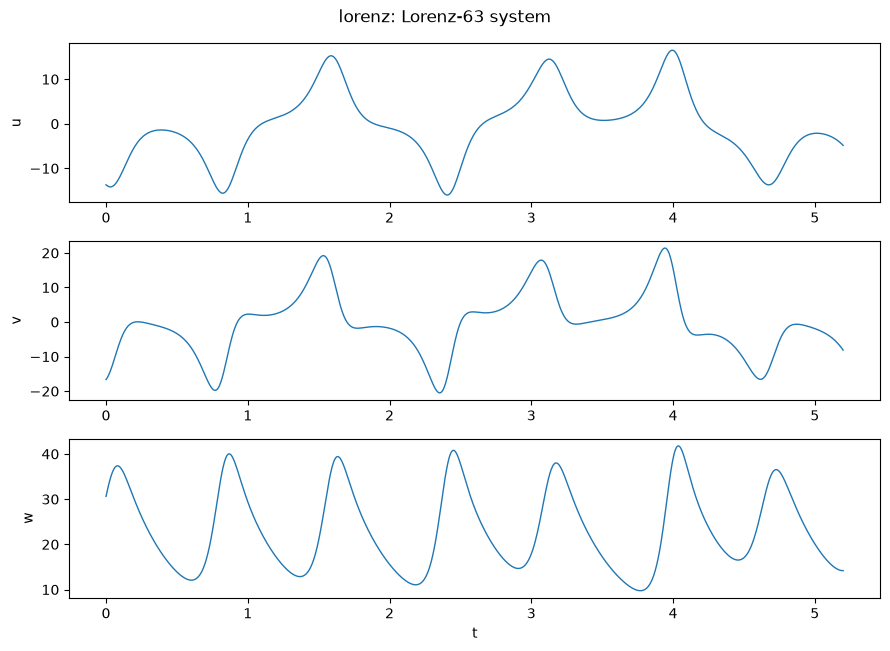

In [6]:
p = datasets.load('lorenz')
print(p.summary())
plot_problem(p); plt.show()

In [7]:
p, report = check('lorenz', noise_levels=[0, 1, 5])
print_check(p, report)

lorenz: Lorenz-63 system
  class: system of ODEs, source: synthetic
  axes: t; data shape: (1041,); variables: u, v, w
  t: [0, 5.2], 1041 points
  truth:
    10.0 * v{power: 1.0} + -10.0 * u{power: 1.0} = du/dx0{power: 1.0}
    28.0 * u{power: 1.0} + -1.0 * u{power: 1.0} * w{power: 1.0} + -1.0 * v{power: 1.0} = dv/dx0{power: 1.0}
    1.0 * u{power: 1.0} * v{power: 1.0} + -2.6666666666666665 * w{power: 1.0} = dw/dx0{power: 1.0}
  notes: sigma = 10, rho = 28, beta = 8/3. Window t in [20.0, 25.2] of the stored run, every 5th sample (gate.py): on the attractor. lorenz.py and the old benchmark used t[:1000], an off-attractor transient.

=== noise 0 % ===
R^2 of the true structure: 1.000000   (du/dx0{power: 1.0})
  term                                                             true       fitted  R^2 lost if dropped
  v{'power': 1.0}                                                    10       9.9945            9.977e-01
  u{'power': 1.0}                                                   -1

In [8]:
from epde_bench.nbcache import cached_run
rec = cached_run('lorenz', variant='default', noise=0.0, seed=0)
print(rec['status'], f"fit {rec.get('fit_seconds', 0):.0f} s", '(from cache)' if rec.get('from_cache') else '')
for i, system in enumerate(rec.get('front', [])):
    print(f'[{i}]' + (' <- compromise pick' if i == rec['metrics']['selected_index'] else ''))
    for eq in system:
        print('    ', eq)
print({k: v for k, v in rec.get('metrics', {}).items() if k != 'best_index'})
if rec['status'] != 'ok':
    print('Search needs attention:', rec.get('error', rec['status']))

ok fit 486 s (from cache)
[0]
     / 0.00879993242379217 * v{power: 3.0} + 0.0 = du/dx0{power: 1.0}
     | 0.6041386315804707 * v{power: 3.0} + -0.06248936354384751 * u{power: 3.0} * w{power: 1.0} + 0.0 = dv/dx0{power: 1.0} * w{power: 1.0}
     \ 0.00183514436568406 * v{power: 3.0} * u{power: 3.0} + 0.0 = dw/dx0{power: 2.0}
[1]
     / -9.994429205124053 * u{power: 1.0} + 9.994478222808224 * v{power: 1.0} + 0.0 = du/dx0{power: 1.0}
     | 0.028867687204828036 * v{power: 3.0} + -0.07194316498511477 * u{power: 3.0} + 0.0 = dv/dx0{power: 1.0}
     \ 1.5113452051020855 * u{power: 2.0} + -0.00300907479435336 * w{power: 3.0} + -0.057291617256933644 * w{power: 2.0} + 0.0 = dw/dx0{power: 1.0}
[2]
     / 0.009732793962379667 * w{power: 3.0} + -7.6692920002618035 * u{power: 2.0} + 6.258679029607694 * v{power: 2.0} + 0.0 = v{power: 1.0} * du/dx0{power: 1.0}
     | -3.223262801877964e-05 * w{power: 2.0} * u{power: 3.0} + 0.0 = dv/dx0{power: 1.0}
     \ 1.4547440390356714 * u{power: 2.0} + -0.153072

In [9]:
from epde_bench.nbcache import cached_run
rec = cached_run('lorenz', variant='default', noise=1.0, seed=0)
print(rec['status'], f"fit {rec.get('fit_seconds', 0):.0f} s", '(from cache)' if rec.get('from_cache') else '')
for i, system in enumerate(rec.get('front', [])):
    print(f'[{i}]' + (' <- compromise pick' if i == rec['metrics']['selected_index'] else ''))
    for eq in system:
        print('    ', eq)
print({k: v for k, v in rec.get('metrics', {}).items() if k != 'best_index'})
if rec['status'] != 'ok':
    print('Search needs attention:', rec.get('error', rec['status']))

ok

 fit 488 s (from cache)
[0]
     / 0.02540413883580828 * u{power: 3.0} * dw/dx0{power: 1.0} + 0.0 = du/dx0{power: 1.0} * v{power: 2.0}
     | -14.094816203890318 * u{power: 2.0} + 9.699274880568373 * v{power: 2.0} + -0.033659053727816975 * dw/dx0{power: 1.0} * u{power: 2.0} + 0.0 = dv/dx0{power: 1.0} * u{power: 1.0}
     \ 0.4651397951767278 * v{power: 2.0} + 0.0 = dw/dx0{power: 1.0}
[1]
     / 2.465172237700375 * v{power: 1.0} + 0.0 = du/dx0{power: 1.0}
     | 0.028798437801611294 * v{power: 3.0} + -0.0718469559716273 * u{power: 3.0} + 0.0 = dv/dx0{power: 1.0}
     \ 1.5047268616595593 * u{power: 2.0} + -0.004632884248467608 * w{power: 3.0} + 0.0 = dw/dx0{power: 1.0}
[2] <- compromise pick
     / 9.97940211574461 * v{power: 1.0} + -9.983502281984462 * u{power: 1.0} + 0.0 = du/dx0{power: 1.0}
     | -13.120569490177548 * u{power: 3.0} + 4.320119136633607 * v{power: 3.0} + 0.0 = dv/dx0{power: 1.0} * u{power: 2.0}
     \ 0.00389524493377503 * w{power: 3.0} + 0.027419499073057945 * w{powe